# Lab Instructions

Find a dataset that interests you. I'd recommend starting on [Kaggle](https://www.kaggle.com/). Read through all of the material about the dataset and download a .CSV file.

1. Write a short summary of the data.  Where did it come from?  How was it collected?  What are the features in the data?  Why is this dataset interesting to you?  

2. Identify 5 interesting questions about your data that you can answer using Pandas methods.  

3. Answer those questions!  You may use any method you want (including LLMs) to help you write your code; however, you should use Pandas to find the answers.  LLMs will not always write code in this way without specific instruction.  

4. Write the answer to your question in a text box underneath the code you used to calculate the answer.



1: The Dataset I chose to analyze is Hypersonic Missile Technology. This dataset came from Kaggle and was collected through open source that Military’s have released. The set features Country of origin, Engine used, Range, Speed, Launching platform, Attack type, Developer, and Propellent. This dataset interests me because it outlines the advance weapons that near-peer adversaries have to project power to the world.

2: 
Question 1: How many hypersonic systems does each country have and who has the most?
Russia           5
China            3
India            2
United States    2
Iran             1
Israel           1
North Korea      1
Russia has the most systems with 5

Question 2: What is the average speed of hypersonic missiles developed by each country?
North Korea             17.0              1       17.0
China                   15.0              3       25.0
Iran                    15.0              1       15.0
India                    7.8              2        8.0
Russia                   7.5              4       10.0
United States            6.5              2        8.0
Israel                   5.0              1        5.0

Question 3: What are the unique types of engines used and how frequently is each used?
scramjet                                       3
solid fuel                                     3
solid-propellant                               1
boost-sustain solid                            1
two-stage solid                                1
booster with ramjet raduga tmkb soyuz tsagi    1
solid rocket                                   1
three-stage solid-fuel rocket                  1
two-stage                                      1
liquid-propellant                              1
The total types of unique engines is 10

Question 4: Which missile has the greater range and what platforms are used?
Top 5 missiles by range:
         model_name country_of_origin  range_km  
8             DF-41             China     15000          
11       Hwasong-12       North Korea      6000          
5        Kh-90 GELA            Russia      4000          
10          Arrow 3            Israel      2400          
1   Kh-47M2 Kinzhal            Russia      2000
Missile with the greatest reported range:
Model: DF-41
Country: China
Range: 15000 km (numeric: 15000 km)
Launch Platform(s): Silo, road-mobile Transporter erector launcher, rail-mobile

Question 5: What is the most common attack type used by these missiles?
The most common attack type used is surface to surface missiles with 3 mentions.

In [27]:
import pandas as pd

missiles_df = pd.read_csv('hypersonic_missiles_military - Sheet1.csv')
missiles_df.head()

,Model Name,Country of Origin,Developed By,Attack Type,Maximum Speed,Range (km),Engine,Propellant,Launch Platform
0,3M22 Zircon,Russia,NPO Mashinostroyeniya,"Hypersonic cruise missile, Anti-ship missile, ...",Mach 9,1000,Scramjet,Liquid,"Submarine, ship"
1,Kh-47M2 Kinzhal,Russia,"Votkinsk Plant State Production Association, JSC",Hypersonic air-launched ballistic missile,Mach 10,2000,Solid-propellant,"Solid, oxidizer",Aircraft
2,R-37,Russia,JSC,Hypersonic air-to-air,Mach 6,400,Boost-Sustain Solid,"Solid, oxidizer",Aircraft
3,BrahMos-II,"India, Russia","Defence Research and Development Organisation,...","Hypersonic cruise missile, Air-launched cruise...",Mach 8,1500,Scramjet,Air,"Ship, submarine, aircraft, mobile launchers"
4,Shaurya,India,"Research Centre Imarat (DRDO), Bharat Dynamics...",Hypersonic surface-to-surface missile,Mach 7.5,1900,Two-stage solid,Solid,"Canisterised transporter erector launcher, silo"



Number of hypersonic missile models by country:
         Country  Count
0         Russia      5
1          China      3
2          India      2
3  United States      2
4           Iran      1
5         Israel      1
6    North Korea      1


<Axes: title={'center': 'Number of Hypersonic Missile Systems'}, xlabel='Country', ylabel='Number of Missile Models'>

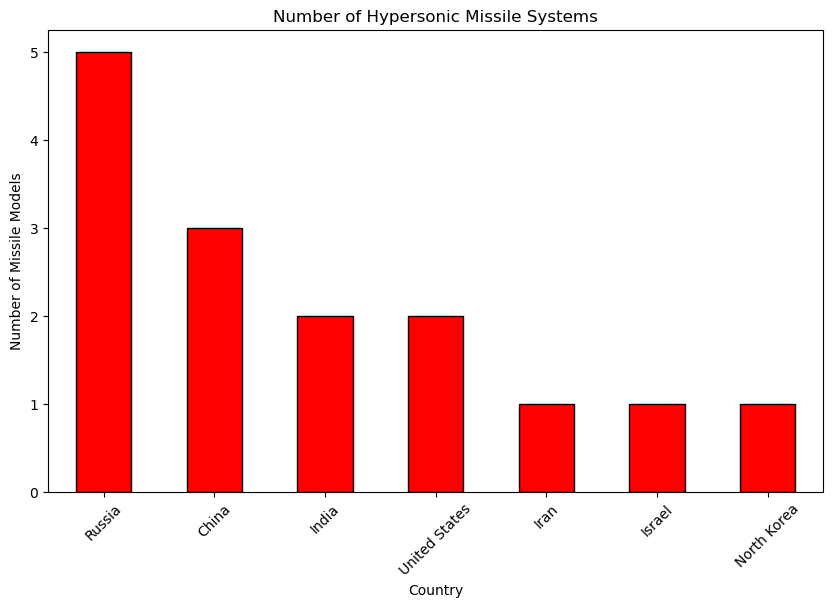

In [21]:
missiles_df.columns = missiles_df.columns.str.strip()

all_countries = (
    missiles_df['country_of_origin']
    .str.split(',')
    .explode()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
)

country_counts = all_countries.value_counts().head(10)

country_df = country_counts.reset_index()
country_df.columns = ['Country', 'Count']

print("\nNumber of hypersonic missile models by country:")
print(country_df)

country_counts.plot(
    kind= 'bar',
    figsize=(10,6),
    color='red',
    edgecolor='black',
    title='Number of Hypersonic Missile Systems',
    xlabel='Country',
    ylabel='Number of Missile Models',
    rot=45)


Average hypersonic missile speed by country (Mach):
               average_speed  missile_count  max_speed
country_clean                                         
North Korea             17.0              1       17.0
China                   15.0              3       25.0
Iran                    15.0              1       15.0
India                    7.8              2        8.0
Russia                   7.5              4       10.0
United States            6.5              2        8.0
Israel                   5.0              1        5.0


<Axes: title={'center': 'Average Maximum Speed of Hypersonic Missiles by Country (Mach)'}, xlabel='Country', ylabel='Average Max Speed (Mach)'>

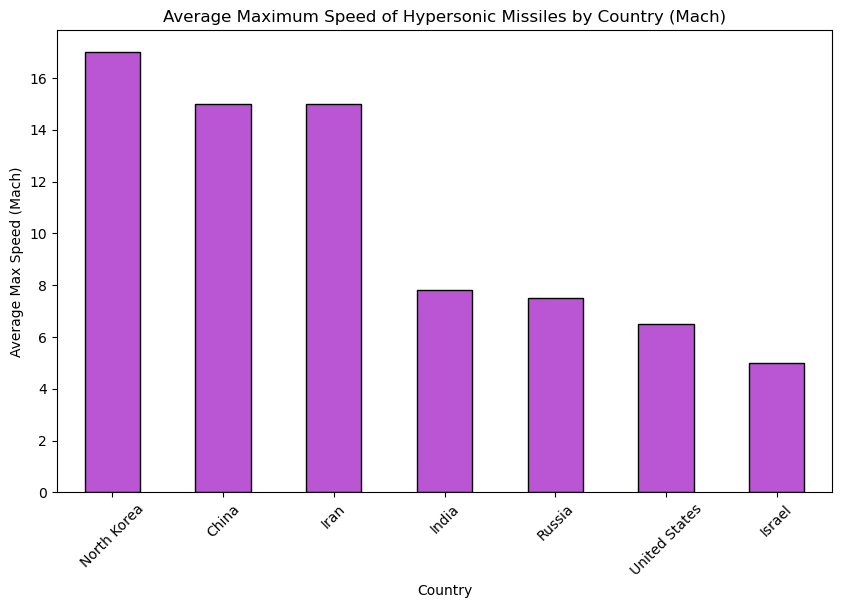

In [26]:
import re
def extract_mach(text):
    if pd.isna(text):
        return None
    text = str(text).lower().strip()
    match = re.search(r'mach\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    match_num = re.search(r'(\d+\.?\d*)', text)
    if match_num:
        return float(match_num.group(1))
    return None

missiles_df['speed_mach'] = missiles_df['maximum_speed'].apply(extract_mach)
missiles_df['country_clean'] = missiles_df['country_of_origin'].str.split(',').str[0].str.strip()

avg_speed_by_country = missiles_df.groupby('country_clean')['speed_mach'].agg(
    average_speed='mean',
    missile_count='count',
    max_speed='max'
).round(1).sort_values('average_speed', ascending=False)

print("\nAverage hypersonic missile speed by country (Mach):")
print(avg_speed_by_country)

avg_speed_by_country['average_speed'].dropna().plot(kind='bar',
    figsize=(10, 6),
    color='mediumorchid',
    edgecolor='black',
    title='Average Maximum Speed of Hypersonic Missiles by Country (Mach)',
    xlabel='Country',
    ylabel='Average Max Speed (Mach)',
    rot=45)


Frequency of each engine/propulsion type (counting multiples per missile):
engine
scramjet                                       3
solid fuel                                     3
solid-propellant                               1
boost-sustain solid                            1
two-stage solid                                1
booster with ramjet raduga tmkb soyuz tsagi    1
solid rocket                                   1
three-stage solid-fuel rocket                  1
two-stage                                      1
liquid-propellant                              1
Name: count, dtype: int64

Total unique engine types mentioned: 10


<Axes: title={'center': 'Frequency of Engine/Propulsion Types in Hypersonic Missiles\n(Counting Multiple Engines per System)'}, xlabel='Engine Type', ylabel='Number of Mentions Across Missiles'>

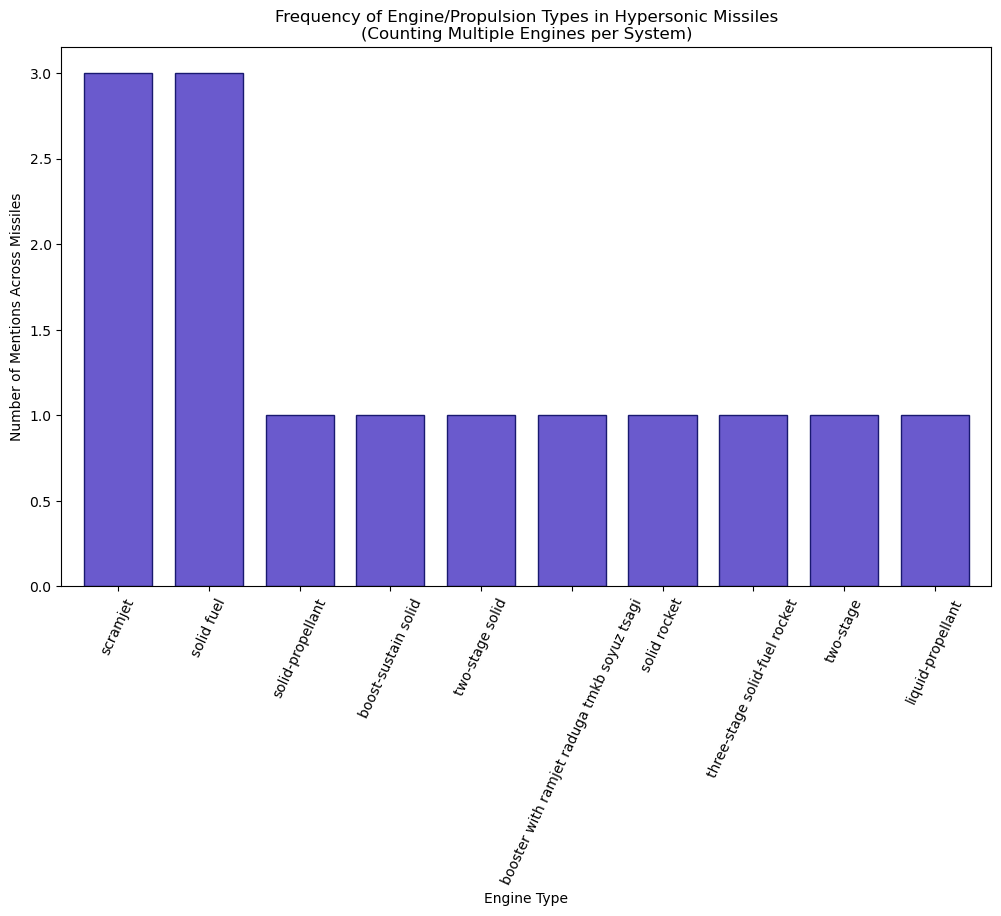

In [48]:
def split_engines(text):
    if pd.isna(text):
        return []
    text = str(text).strip()
    text = text.replace('/', ',').replace(' or ', ',').replace(' & ', ',').replace('+', ',').replace('and', ',')
    engines = [e.strip().lower() for e in text.split(',') if e.strip()]
    return engines
exploded_engines = missiles_df['engine'].apply(split_engines).explode()
exploded_engines = exploded_engines[exploded_engines.str.strip() != '']

engine_counts = exploded_engines.value_counts().head(15)

print("\nFrequency of each engine/propulsion type (counting multiples per missile):")
print(engine_counts)

print(f"\nTotal unique engine types mentioned: {exploded_engines.nunique()}")

engine_df = engine_counts.reset_index()
engine_df.columns = ['Engine_Type', 'Count']

engine_df.plot(
    x='Engine_Type',
    y='Count',
    kind='bar',
    figsize=(12, 7),              
    color='slateblue',
    edgecolor='midnightblue',
    title='Frequency of Engine/Propulsion Types in Hypersonic Missiles\n(Counting Multiple Engines per System)',
    xlabel='Engine Type',
    ylabel='Number of Mentions Across Missiles',
    rot=65,                       
    width=0.75,
    legend=False
)


Missile with the greatest reported range:
Model: DF-41
Country: China
Range: 15000 km (numeric: 15000 km)
Launch Platform(s): Silo, road-mobile Transporter erector launcher, rail-mobile

Top 5 missiles by range:
         model_name country_of_origin  range_km  range_numeric  \
8             DF-41             China     15000          15000   
11       Hwasong-12       North Korea      6000           6000   
5        Kh-90 GELA            Russia      4000           4000   
10          Arrow 3            Israel      2400           2400   
1   Kh-47M2 Kinzhal            Russia      2000           2000   

                                      launch_platform  
8   Silo, road-mobile Transporter erector launcher...  
11                                  MAZ-based vehicle  
5                                      Aircraft, ship  
10                                               Silo  
1                                            Aircraft  


<Axes: title={'center': 'Top 5 Hypersonic Missiles by Reported Range (km)'}, xlabel='Range (km)', ylabel='Missile Model'>

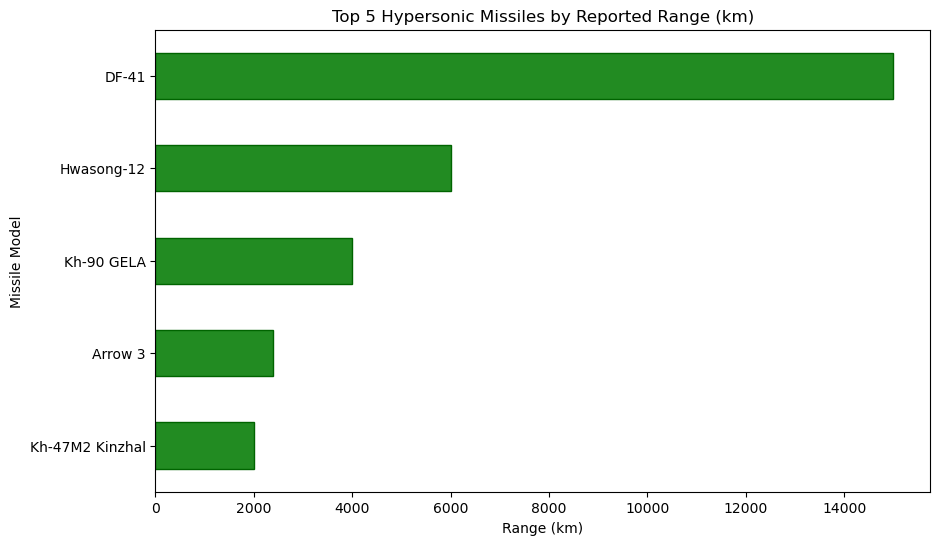

In [47]:
missiles_df['range_numeric'] = pd.to_numeric(missiles_df['range_km'], errors='coerce')

max_range_row = missiles_df.loc[missiles_df['range_numeric'].idxmax()]

print("\nMissile with the greatest reported range:")
print(f"Model: {max_range_row['model_name']}")
print(f"Country: {max_range_row['country_of_origin']}")
print(f"Range: {max_range_row['range_km']} km (numeric: {max_range_row['range_numeric']} km)")
print(f"Launch Platform(s): {max_range_row['launch_platform']}")

top_range = missiles_df.nlargest(5, 'range_numeric')[['model_name', 'country_of_origin', 'range_km', 'range_numeric', 'launch_platform']]

print("\nTop 5 missiles by range:")
print(top_range)

top_range.set_index('model_name')['range_numeric'].sort_values(ascending=True).plot(
    kind='barh',
    figsize=(10, 6),
    color='forestgreen',
    edgecolor='darkgreen',
    title='Top 5 Hypersonic Missiles by Reported Range (km)',
    xlabel='Range (km)',
    ylabel='Missile Model',
)

In [59]:
def split_attacks(text):
    if pd.isna(text):
        return []
    text = str(text).strip()
    
    text = text.replace('and', ',').replace('/', ',').replace(';', ',')
   
    types = [t.strip().lower() for t in text.split(',') if t.strip()]
    return types

exploded = missiles_df['attack_type'].apply(split_attacks).explode()
exploded = exploded[exploded.str.strip() != '']

def simplify_attack(t):
    t = str(t).lower().strip()
    if 'anti-ship' in t or 'anti ship' in t or 'asbm' in t:
        return 'Anti-ship'
    if 'land-attack' in t or 'land attack' in t or 'cruise' in t and 'land' in t:
        return 'Land-attack / Cruise'
    if 'air-to-air' in t:
        return 'Air-to-air'
    if 'air-to-surface' in t or 'air-to-ground' in t:
        return 'Air-to-surface'
    if 'surface-to-surface' in t or 'standoff' in t:
        return 'Surface-to-surface'
    if 'submarine-launched' in t or 'slcm' in t:
        return 'Submarine-launched'
    if 'ballistic' in t:
        if 'intercontinental' in t or 'icbm' in t:
            return 'ICBM'
        if 'intermediate' in t or 'medium' in t:
            return 'IRBM / MRBM'
        return 'Ballistic (other)'
    if 'hypersonic cruise' in t or 'cruise' in t:
        return 'Hypersonic cruise'
    if 'anti-ballistic' in t:
        return 'Anti-ballistic'
    return 'Other / Unclassified'

simple_counts = missiles_df['attack_type'].apply(split_attacks).apply(lambda x: [simplify_attack(t) for t in x]).explode()

simple_counts.value_counts(dropna=False)

most_common_cat = simple_counts.idxmax()
print(f"\nMost common attack category: {most_common_cat} ({simple_counts.max()} mentions)")



Most common attack category: 3 (Surface-to-surface mentions)
